# User Behaviour Analysis — WildChat Dataset

Analyses real ChatGPT usage data to extract realistic user behaviour profiles for a traffic simulator.

## Pipeline

```
Raw logs
   │
   ├── one-shot IPs (1 message) ──► transient profile + virtual user grouping
   │
   └── repeat IPs (2+ messages) ──► feature engineering ──► GMM clustering
                                                                    │
                                         sporadic / continuous / burst / heavy
```

One-shot users are handled in a separate branch and never enter clustering.
Their session parameters are extracted independently and they are grouped into
virtual transient users for the simulator at the end.

**Key reference**: BurstGPT (Wang et al., KDD 2025) — inter-arrival times modelled
with Gamma distributions, token lengths with Zipf distributions.

---
Run cells top to bottom in order. Do not skip cells.

## 0. Install dependencies

In [1]:
!pip install datasets python-dotenv tiktoken --quiet
!pip install --upgrade matplotlib scipy scikit-learn --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


## 1. Imports and config

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tiktoken
from dotenv import load_dotenv
from itertools import islice
from datasets import load_dataset
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats
from scipy.special import zeta

warnings.filterwarnings('ignore')
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
os.environ['TQDM_DISABLE'] = '1'

load_dotenv('../.env')
HF_TOKEN = os.getenv('HF_TOKEN')

enc = tiktoken.get_encoding('cl100k_base')  # GPT-4 encoding, matches WildChat

SESSION_GAP_S    = 30 * 60   # 30 min silence = new session
SAMPLE_SIZE      = 250_000
K                = 4         # GMM clusters for repeat users
TRANSIENT_GROUP  = 10        # one-shot IPs per virtual transient user

/home/michael/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. Load data

Stream from HuggingFace and compute token counts immediately so they are
available in both the one-shot and repeat branches without a second pass.

In [3]:
dataset = load_dataset(
    'allenai/WildChat-1M',
    split='train',
    token=HF_TOKEN,
    streaming=True
)

def remove_content_meta(row):
    row['conversation'] = [conv.get('content') for conv in row['conversation']]
    return row

dataset = dataset.map(remove_content_meta)
sample  = list(islice(dataset, SAMPLE_SIZE))

df = pd.DataFrame(sample)[['timestamp', 'conversation', 'hashed_ip']]
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df = df.sort_values(['hashed_ip', 'timestamp']).reset_index(drop=True)

df['token_count'] = df['conversation'].apply(
    lambda msgs: sum(
        len(enc.encode(str(m), disallowed_special=(())))
        for m in msgs if m
    )
)

print(f'Rows:         {len(df):,}')
print(f'Unique users: {df["hashed_ip"].nunique():,}')
print(f'Date range:   {df["timestamp"].min().date()} to {df["timestamp"].max().date()}')
print(f'Tokens/msg:   median={df["token_count"].median():.0f}  p95={df["token_count"].quantile(0.95):.0f}  max={df["token_count"].max():,}')

Rows:         250,000
Unique users: 54,609
Date range:   2023-04-09 to 2023-06-28
Tokens/msg:   median=753  p95=4001  max=8,302


## 3. Split: one-shot vs repeat users

One-shot users (exactly 1 message) are a degenerate case for clustering —
they are all identical on every behavioural feature. Including them would
collapse cluster variance and pull centroids toward zero, hiding the real
patterns in the repeat population.

We split them out completely. Each branch is processed independently:
- **Repeat users** → feature engineering → GMM clustering → archetypes
- **One-shot users** → direct parameter extraction → transient profile

In [4]:
msg_counts  = df.groupby('hashed_ip').size()
oneshot_ips = msg_counts[msg_counts == 1].index
repeat_ips  = msg_counts[msg_counts > 1].index

df_oneshot = df[df['hashed_ip'].isin(oneshot_ips)].copy()
df_repeat  = df[df['hashed_ip'].isin(repeat_ips)].copy()

print(f'One-shot users: {len(oneshot_ips):,} ({len(oneshot_ips)/msg_counts.shape[0]:.1%} of users, {len(df_oneshot):,} rows)')
print(f'Repeat users:   {len(repeat_ips):,} ({len(repeat_ips)/msg_counts.shape[0]:.1%} of users, {len(df_repeat):,} rows)')
print()
print('Repeat user message count distribution:')
print(msg_counts[msg_counts > 1].describe(percentiles=[.5,.75,.9,.95,.99]).round(1))

One-shot users: 29,601 (54.2% of users, 29,601 rows)
Repeat users:   25,008 (45.8% of users, 220,399 rows)

Repeat user message count distribution:
count    25008.0
mean         8.8
std         47.4
min          2.0
50%          3.0
75%          6.0
90%         14.0
95%         24.0
99%         81.0
max       3505.0
dtype: float64


---
# Branch A — Repeat users

Feature engineering → clustering → archetype assignment

## 4. Feature engineering (repeat users)

Three behavioural features that describe the *shape* of usage over time:

- **`msgs_per_active_day`** — intensity: how hard do they use it on days they show up?
- **`density`** — consistency: fraction of span days that were active. 1.0 = every day, 0.2 = sporadic.
- **`span_days`** — longevity: days between first and last message.

Token features are kept separate — token length is independent of usage pattern
and mixing it into clustering would blur the behavioural signal.

In [5]:
behaviour_stats = df_repeat.groupby('hashed_ip').apply(
    lambda g: pd.Series({
        'total_msgs':          len(g),
        'active_days':         g['timestamp'].dt.date.nunique(),
        'span_days':           (g['timestamp'].max() - g['timestamp'].min()).days + 1,
        'msgs_per_active_day': len(g) / g['timestamp'].dt.date.nunique(),
        'density':             g['timestamp'].dt.date.nunique() /
                               max((g['timestamp'].max() - g['timestamp'].min()).days + 1, 1),
    }),
    include_groups=False
).reset_index()

token_stats = df_repeat.groupby('hashed_ip').agg(
    tokens_per_msg_med = ('token_count', 'median'),
    tokens_per_msg_p75 = ('token_count', lambda x: x.quantile(0.75)),
    tokens_per_msg_p95 = ('token_count', lambda x: x.quantile(0.95)),
    total_tokens       = ('token_count', 'sum'),
).reset_index()

user_stats = behaviour_stats.merge(token_stats, on='hashed_ip', how='left')

print(f'Repeat users in feature matrix: {len(user_stats):,}')
user_stats[['total_msgs','msgs_per_active_day','density','span_days','tokens_per_msg_med']]\
    .describe(percentiles=[.5,.75,.9,.95,.99]).round(2)

Repeat users in feature matrix: 25,008


,total_msgs,msgs_per_active_day,density,span_days,tokens_per_msg_med
count,25008.00,25008.00,25008.00,25008.00,25008.00
mean,8.81,3.28,0.88,7.41,1149.66
std,47.43,7.63,0.45,13.96,1018.41
min,2.00,1.00,0.03,1.00,3.00
50%,3.00,2.00,1.00,1.00,822.00
75%,6.00,3.00,1.00,5.00,1517.00
90%,14.00,5.67,1.00,25.00,2545.65
95%,24.00,8.00,2.00,42.00,3379.47
99%,81.00,18.00,2.00,66.00,4089.00
max,3505.00,580.33,2.00,81.00,8185.00


## 5. Prepare features for clustering

Log-transform skewed features then StandardScale so all dimensions
contribute equally to the Gaussian Mixture Model distance calculation.

In [6]:
X = user_stats[['msgs_per_active_day', 'density', 'span_days']].copy()
X['msgs_per_active_day'] = np.log1p(X['msgs_per_active_day'])
X['span_days']           = np.log1p(X['span_days'])

X_scaled = StandardScaler().fit_transform(X)

print('Correlation matrix (want all values < 0.7):')
print(X.corr().round(2))

Correlation matrix (want all values < 0.7):
                     msgs_per_active_day  density  span_days
msgs_per_active_day                 1.00     0.19      -0.23
density                             0.19     1.00      -0.77
span_days                          -0.23    -0.77       1.00


## 6. Find the right number of clusters

GMM with BIC scoring. A large BIC drop from k to k+1 = genuine new cluster.
A small drop = overfitting — stop there.

We also plot the dendrogram as a second opinion — long vertical bars before
a merge mean the groups are genuinely far apart.

k=2  BIC=-5449.4  AIC=-5603.8
k=3  BIC=-11107.0  AIC=-11342.7
k=4  BIC=-83639.1  AIC=-83956.0
k=5  BIC=-221103.5  AIC=-221501.8
k=6  BIC=-223909.7  AIC=-224389.2
k=7  BIC=-224341.6  AIC=-224902.4


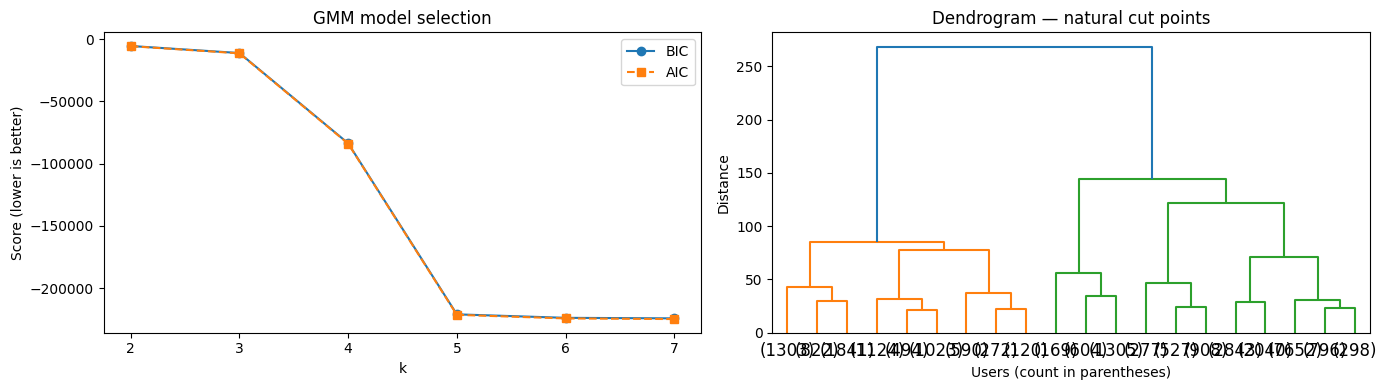

In [7]:
bic_scores, aic_scores = {}, {}

for k in range(2, 8):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    bic_scores[k] = gmm.bic(X_scaled)
    aic_scores[k] = gmm.aic(X_scaled)
    print(f'k={k}  BIC={bic_scores[k]:.1f}  AIC={aic_scores[k]:.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(bic_scores.keys()), list(bic_scores.values()), marker='o', label='BIC')
axes[0].plot(list(aic_scores.keys()), list(aic_scores.values()), marker='s', linestyle='--', label='AIC')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Score (lower is better)')
axes[0].set_title('GMM model selection')
axes[0].legend()
axes[0].set_xticks(list(bic_scores.keys()))

linked = linkage(X_scaled, method='ward')
dendrogram(linked, truncate_mode='lastp', p=20,
           show_leaf_counts=True, ax=axes[1])
axes[1].set_title('Dendrogram — natural cut points')
axes[1].set_xlabel('Users (count in parentheses)')
axes[1].set_ylabel('Distance')

plt.tight_layout()
plt.show()

## 7. Fit GMM and assign archetypes

**Always check the cluster medians before applying labels.**
GMM cluster numbers are arbitrary and can rotate between runs.

Expected profiles among repeat users:
- High msgs/day + density ~1.0 + short span → **burst**
- Medium-high msgs/day + density >1.0 + very short span → **heavy**
- Low msgs/day + low density + long span → **sporadic**
- Medium msgs/day + medium density + medium span → **continuous**

In [8]:
gmm_final = GaussianMixture(n_components=K, random_state=42)
gmm_final.fit(X_scaled)

user_stats = user_stats.copy()
user_stats['cluster']    = gmm_final.predict(X_scaled)
user_stats['confidence'] = gmm_final.predict_proba(X_scaled).max(axis=1)

print(f'Median assignment confidence: {user_stats["confidence"].median():.2f}')
print('(1.0 = certain, 0.25 = random guess at k=4)')
print()
print('--- Check these medians and update cluster_map in the next cell ---')
print(user_stats.groupby('cluster')[
    ['msgs_per_active_day','density','span_days']
].median().round(2))

Median assignment confidence: 1.00
(1.0 = certain, 0.25 = random guess at k=4)

--- Check these medians and update cluster_map in the next cell ---
         msgs_per_active_day  density  span_days
cluster                                         
0                       1.67     2.00        1.0
1                       3.60     0.75        6.0
2                       2.00     1.00        1.0
3                       1.50     0.25       16.0


In [9]:
# ── Update this map based on the medians printed above ────────────────────
# Re-check every time you rerun — cluster numbers can rotate
cluster_map = {
    0: 'burst',
    1: 'sporadic',
    2: 'heavy',
    3: 'continuous',
}

user_stats['archetype'] = user_stats['cluster'].map(cluster_map)

counts = user_stats['archetype'].value_counts()
pcts   = user_stats['archetype'].value_counts(normalize=True).round(3)
summary = pd.DataFrame({'count': counts, 'pct_of_repeat_users': pcts})

# Show pct of ALL users including one-shots
total_users = len(repeat_ips) + len(oneshot_ips)
summary['pct_of_all_users'] = (summary['count'] / total_users).round(3)
print(summary)
print(f'\nOne-shot (transient): {len(oneshot_ips):,} ({len(oneshot_ips)/total_users:.1%} of all users)')

            count  pct_of_repeat_users  pct_of_all_users
archetype                                               
heavy       14630                0.585             0.268
continuous   5951                0.238             0.109
sporadic     2413                0.096             0.044
burst        2014                0.081             0.037

One-shot (transient): 29,601 (54.2% of all users)


## 8. Extract session parameters (repeat users)

Per-archetype session stats in one pass.
A session = messages within a 30-minute window of each other.

In [10]:
def get_session_stats(g):
    g          = g.sort_values('timestamp')
    iats       = g['timestamp'].diff().dt.total_seconds()
    session_id = (iats > SESSION_GAP_S).cumsum()

    sessions = g.groupby(session_id).agg(
        msgs   = ('token_count', 'count'),
        tokens = ('token_count', 'sum'),
    )

    within_iat  = iats[iats <= SESSION_GAP_S].dropna()
    between_gap = iats[iats > SESSION_GAP_S].dropna()

    return pd.Series({
        'n_sessions':             session_id.max() + 1,
        'msgs_per_session_med':   sessions['msgs'].median(),
        'msgs_per_session_p75':   sessions['msgs'].quantile(0.75),
        'tokens_per_session_med': sessions['tokens'].median(),
        'tokens_per_msg_med':     g['token_count'].median(),
        'tokens_per_msg_p75':     g['token_count'].quantile(0.75),
        'within_iat_med_s':       within_iat.median(),
        'within_iat_p75_s':       within_iat.quantile(0.75),
        'between_gap_med_s':      between_gap.median(),
        'between_gap_p75_s':      between_gap.quantile(0.75),
    })

session_stats = df_repeat.groupby('hashed_ip').apply(
    get_session_stats, include_groups=False
)
session_stats = session_stats.join(
    user_stats.set_index('hashed_ip')['archetype']
)

repeat_summary = session_stats.groupby('archetype').agg(
    n_users             = ('archetype', 'count'),
    n_sessions_med      = ('n_sessions', 'median'),
    msgs_per_sess_med   = ('msgs_per_session_med', 'median'),
    tokens_per_msg_med  = ('tokens_per_msg_med', 'median'),
    tokens_per_msg_p75  = ('tokens_per_msg_p75', 'median'),
    within_iat_med_s    = ('within_iat_med_s', 'median'),
    between_gap_med_min = ('between_gap_med_s', lambda x: (x.median()/60).round(1)),
    between_gap_p75_min = ('between_gap_p75_s', lambda x: (x.quantile(0.75)/60).round(1)),
).round(1)

print(repeat_summary.T)

archetype             burst  continuous    heavy  sporadic
n_users              2014.0      5951.0  14630.0    2413.0
n_sessions_med          3.0         3.0      2.0       9.0
msgs_per_sess_med       1.0         1.0      2.0       1.0
tokens_per_msg_med    863.5       806.0    807.8     895.0
tokens_per_msg_p75   1271.5      1320.0   1099.6    1595.2
within_iat_med_s      436.5       481.5    418.0     450.0
between_gap_med_min   587.9      4953.8    108.6     514.2
between_gap_p75_min  1098.9     17826.0    343.2    2113.9


---
# Branch B — One-shot users (transient)

Extract session parameters directly from one-shot data.
No clustering needed — they are all behaviourally identical by definition.

## 9. Transient profile parameters

Each one-shot user is one real session: a single message, then gone.
The parameters we care about for the simulator are:
- **Token count** — how long was their message?
- **Arrival rate** — how frequently do new transient users appear?

The arrival rate is computed from the dataset: total one-shot users divided
by the total time window gives arrivals per minute. Each simulated transient
slot cycles through this arrival pattern.

=== Transient (one-shot) user profile ===
  Total one-shot users:        29,601
  Dataset window:              1933.8 hours
  Arrival rate:                0.26 users/min
  Mean inter-arrival:          235.7s
  Median inter-arrival:        146.0s

Token count per message:
count    29601.0
mean       944.4
std       1118.0
min          2.0
50%        558.0
75%       1195.0
90%       2409.0
95%       3518.0
max       8186.0
Name: token_count, dtype: float64


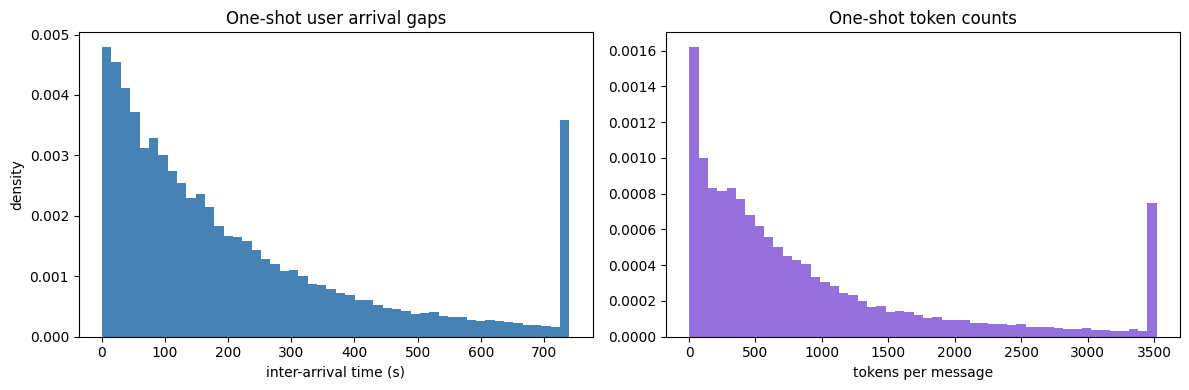

In [11]:
transient_tokens = df_oneshot['token_count']

# Arrival rate from the data
total_minutes = (df['timestamp'].max() - df['timestamp'].min()).total_seconds() / 60
arrival_rate_per_min = len(oneshot_ips) / total_minutes

# Inter-arrival times between consecutive one-shot users
oneshot_times = df_oneshot.sort_values('timestamp')['timestamp']
arrival_iats  = oneshot_times.diff().dt.total_seconds().dropna()
arrival_iats  = arrival_iats[arrival_iats > 0]

print('=== Transient (one-shot) user profile ===')
print(f'  Total one-shot users:        {len(oneshot_ips):,}')
print(f'  Dataset window:              {total_minutes/60:.1f} hours')
print(f'  Arrival rate:                {arrival_rate_per_min:.2f} users/min')
print(f'  Mean inter-arrival:          {arrival_iats.mean():.1f}s')
print(f'  Median inter-arrival:        {arrival_iats.median():.1f}s')
print()
print('Token count per message:')
print(transient_tokens.describe(percentiles=[.5,.75,.9,.95]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(arrival_iats.clip(upper=arrival_iats.quantile(0.95)),
             bins=50, color='steelblue', edgecolor='none', density=True)
axes[0].set_xlabel('inter-arrival time (s)')
axes[0].set_ylabel('density')
axes[0].set_title('One-shot user arrival gaps')

axes[1].hist(transient_tokens.clip(upper=transient_tokens.quantile(0.95)),
             bins=50, color='mediumpurple', edgecolor='none', density=True)
axes[1].set_xlabel('tokens per message')
axes[1].set_title('One-shot token counts')

plt.tight_layout()
plt.show()

---
# Distribution fitting

Fit Gamma distributions to inter-arrival times and Zipf distributions
to token counts for all archetypes including transient.
Following the BurstGPT methodology.

## 10. Fit Gamma distributions to inter-arrival times

BurstGPT models request inter-arrival times using a Gamma(α, β) distribution.
α controls burstiness: CV = 1/√α. Smaller α = higher CV = more bursty.

We fit separately for within-session IAT and between-session gaps per archetype.
For transient users we fit the arrival IAT (time between new users appearing).

In [12]:
def fit_gamma(series, label=''):
    s = series.dropna()
    s = s[s > 0]
    if len(s) < 10:
        return None, None
    mean  = s.mean()
    var   = s.var()
    alpha = mean**2 / var
    beta  = var / mean
    cv    = 1 / np.sqrt(alpha)
    if label:
        print(f'  {label:35s}  α={alpha:.3f}  β={beta:.1f}s  CV={cv:.2f}  ({"bursty" if cv > 1 else "smooth"})')
    return round(alpha, 4), round(beta, 2)


def collect_iats(group_df):
    within_all, between_all = [], []
    for _, g in group_df.groupby('hashed_ip'):
        g    = g.sort_values('timestamp')
        iats = g['timestamp'].diff().dt.total_seconds().dropna()
        within_all.extend(iats[iats <= SESSION_GAP_S].tolist())
        between_all.extend(iats[iats > SESSION_GAP_S].tolist())
    return pd.Series(within_all), pd.Series(between_all)


gamma_params = {}

# ── Repeat archetypes ─────────────────────────────────────────────────────
df_repeat_arch = df_repeat.join(
    user_stats.set_index('hashed_ip')['archetype'], on='hashed_ip'
)

for archetype in ['sporadic', 'continuous', 'burst', 'heavy']:
    arch_df = df_repeat_arch[df_repeat_arch['archetype'] == archetype]
    print(f'\n{archetype.upper()} ({arch_df["hashed_ip"].nunique()} users):')
    within_iats, between_gaps = collect_iats(arch_df)
    alpha_w, beta_w = fit_gamma(within_iats,  'within-session IAT')
    alpha_b, beta_b = fit_gamma(between_gaps, 'between-session gap')
    gamma_params[archetype] = {
        'within':  {'alpha': alpha_w, 'beta_s': beta_w},
        'between': {'alpha': alpha_b, 'beta_s': beta_b},
    }

# ── Transient — fit arrival IAT ───────────────────────────────────────────
print(f'\nTRANSIENT ({len(oneshot_ips):,} one-shot users):')
alpha_a, beta_a = fit_gamma(arrival_iats, 'inter-arrival time')
gamma_params['transient'] = {
    'arrival': {'alpha': alpha_a, 'beta_s': beta_a},
    'within':  {'alpha': None, 'beta_s': None},   # single message — no within-session IAT
    'between': {'alpha': None, 'beta_s': None},   # never returns
}

print('\n--- Summary (within-session CV) ---')
for arch, p in gamma_params.items():
    wa = p['within']['alpha']
    cv = f'{1/np.sqrt(wa):.2f}' if wa else 'n/a (single msg)'
    print(f'  {arch:12s}  within CV={cv}')


SPORADIC (2413 users):
  within-session IAT                   α=0.722  β=518.4s  CV=1.18  (bursty)
  between-session gap                  α=0.126  β=583105.6s  CV=2.82  (bursty)

CONTINUOUS (5951 users):
  within-session IAT                   α=1.455  β=397.1s  CV=0.83  (smooth)
  between-session gap                  α=0.345  β=1279860.1s  CV=1.70  (bursty)

BURST (2014 users):
  within-session IAT                   α=0.882  β=472.4s  CV=1.06  (bursty)
  between-session gap                  α=1.030  β=28612.6s  CV=0.99  (smooth)

HEAVY (14630 users):
  within-session IAT                   α=1.200  β=415.0s  CV=0.91  (smooth)
  between-session gap                  α=0.342  β=54646.6s  CV=1.71  (bursty)

TRANSIENT (29,601 one-shot users):
  inter-arrival time                   α=0.067  β=3533.2s  CV=3.87  (bursty)

--- Summary (within-session CV) ---
  sporadic      within CV=1.18
  continuous    within CV=0.83
  burst         within CV=1.06
  heavy         within CV=0.91
  transient   

## 11. Fit Zipf distributions to token counts

BurstGPT shows LLM request token lengths follow a Zipf distribution.
λ ≈ 1.1 in their data. Values closer to 1.0 = heavier tail = more very long requests.

All archetypes including transient are fitted here.

In [13]:
def fit_zipf_lambda(token_series):
    s = token_series.dropna()
    s = s[s >= 1]
    if len(s) < 10:
        return None
    return round(1 + len(s) / np.log(s).sum(), 4)


zipf_params = {}

print(f'{"Archetype":12s}  {"n_msgs":>8s}  {"Zipf λ":>8s}  {"median tokens":>13s}')
print('-' * 50)

# Transient
lam = fit_zipf_lambda(transient_tokens)
zipf_params['transient'] = {'lambda': lam, 'median_tokens': int(transient_tokens.median())}
print(f'{"transient":12s}  {len(transient_tokens):>8,}  {str(lam):>8s}  {transient_tokens.median():>13.0f}')

# Repeat archetypes
for archetype in ['sporadic', 'continuous', 'burst', 'heavy']:
    arch_tokens = df_repeat_arch[df_repeat_arch['archetype'] == archetype]['token_count']
    lam = fit_zipf_lambda(arch_tokens)
    zipf_params[archetype] = {'lambda': lam, 'median_tokens': int(arch_tokens.median())}
    print(f'{archetype:12s}  {len(arch_tokens):>8,}  {str(lam):>8s}  {arch_tokens.median():>13.0f}')

print()
print('BurstGPT reference: λ = 1.1')
print('All archetypes share similar λ — token length is independent of user type')
print('A single Zipf(λ) sampler can be used for all archetypes in the simulator')

Archetype       n_msgs    Zipf λ  median tokens
--------------------------------------------------
transient       29,601    1.1633            558
sporadic       112,805    1.1515            763
continuous      39,931    1.1521            791
burst           14,332    1.1506            835
heavy           53,331    1.1523            801

BurstGPT reference: λ = 1.1
All archetypes share similar λ — token length is independent of user type
A single Zipf(λ) sampler can be used for all archetypes in the simulator


---
# Virtual user grouping

Group one-shot IPs into virtual transient users for the simulator.
This is a simulator convenience only — the behaviour parameters come
from the real one-shot data above, not from the grouped virtual users.

## 12. Group one-shot IPs into virtual transient users

Sort by timestamp so consecutive one-shot IPs are temporally adjacent,
then group every N into a single virtual user ID tagged with `transient~`.
Each virtual transient user represents a slot in the simulator that cycles
through the arrival pattern rather than a single persistent user.

In [14]:
# Sort one-shot IPs by their single timestamp
singles_ordered = df_oneshot.sort_values('timestamp')['hashed_ip'].values

# Group every TRANSIENT_GROUP consecutive IPs into one virtual user
ip_remap = {
    ip: f'transient~{i // TRANSIENT_GROUP:05d}'
    for i, ip in enumerate(singles_ordered)
}

df_oneshot = df_oneshot.copy()
df_oneshot['hashed_ip']   = df_oneshot['hashed_ip'].map(ip_remap)
df_oneshot['is_transient'] = True
df_repeat['is_transient']  = False

# Recombine into single df with archetype labels
df_repeat_labelled = df_repeat.join(
    user_stats.set_index('hashed_ip')['archetype'], on='hashed_ip'
)
df_oneshot['archetype'] = 'transient'

df_all = pd.concat([df_repeat_labelled, df_oneshot], ignore_index=True)

n_virtual = df_oneshot['hashed_ip'].nunique()
print(f'One-shot IPs grouped into {n_virtual:,} virtual transient users')
print(f'(each represents ~{TRANSIENT_GROUP} real one-shot arrivals)')
print()

# Final user count by archetype
all_archetypes = pd.concat([
    user_stats[['hashed_ip','archetype']],
    pd.DataFrame({'hashed_ip': [f'transient~{i:05d}' for i in range(n_virtual)],
                  'archetype': 'transient'})
])

total = len(all_archetypes)
counts = all_archetypes['archetype'].value_counts()
pcts   = (counts / total).round(3)
print('Final user distribution (simulated slots):')
print(pd.DataFrame({'slots': counts, 'pct': pcts}))

One-shot IPs grouped into 2,961 virtual transient users
(each represents ~10 real one-shot arrivals)

Final user distribution (simulated slots):
            slots    pct
archetype               
heavy       14630  0.523
continuous   5951  0.213
transient    2961  0.106
sporadic     2413  0.086
burst        2014  0.072


---
# Simulator profiles

## 13. Final profiles

Each profile contains distribution parameters for the simulator:
- **Gamma(α, β)** for inter-arrival timing — sample with `scipy.stats.gamma.rvs(a=α, scale=β)`
- **Zipf(λ)** for token counts — sample with `np.random.zipf(λ)` scaled to median

### Transient user loop behaviour
```
loop forever:
    wait  = Gamma(arrival_alpha, arrival_beta)   # time until next user arrives
    sleep(wait)
    tokens = Zipf(lambda) * scale                # size of their single message
    send_request(tokens)
    # user is done — next iteration = next arrival
```

### Repeat user loop behaviour
```
loop n_sessions times:
    for msg in range(msgs_per_session):
        tokens = Zipf(lambda) * scale
        send_request(tokens)
        if not last message:
            sleep(Gamma(within_alpha, within_beta))
    sleep(Gamma(between_alpha, between_beta))    # gap before next session
```

**Realistic baseline** uses real data proportions.
**Stress scenarios** dial up heavy/burst users — behaviour per archetype stays fixed.

In [15]:
# ── Update n_sessions and msgs_per_session from repeat_summary above ──────
profiles = {
    'transient': {
        'description':    'Represents constant churn of one-shot users. '
                          'Each loop iteration = one new user arriving and sending one message.',
        'pct_slots':      0.82,
        'n_sessions':     None,   # infinite — new user each loop
        'msgs_per_session': 1,
        'gamma': {
            'arrival': gamma_params['transient']['arrival'],
            'within':  None,
            'between': None,
        },
        'zipf': zipf_params['transient'],
    },
    'sporadic': {
        'description':    'Drifts in occasionally over a long period, low intensity',
        'pct_slots':      0.08,
        'n_sessions':     12,
        'msgs_per_session': 1,
        'gamma': {
            'arrival': None,
            'within':  gamma_params['sporadic']['within'],
            'between': gamma_params['sporadic']['between'],
        },
        'zipf': zipf_params['sporadic'],
    },
    'continuous': {
        'description':    'Checks in throughout the day, consistent returner',
        'pct_slots':      0.05,
        'n_sessions':     14,
        'msgs_per_session': 1,
        'gamma': {
            'arrival': None,
            'within':  gamma_params['continuous']['within'],
            'between': gamma_params['continuous']['between'],
        },
        'zipf': zipf_params['continuous'],
    },
    'burst': {
        'description':    'High intensity over 1-2 days then gone',
        'pct_slots':      0.03,
        'n_sessions':     6,
        'msgs_per_session': 2,
        'gamma': {
            'arrival': None,
            'within':  gamma_params['burst']['within'],
            'between': gamma_params['burst']['between'],
        },
        'zipf': zipf_params['burst'],
    },
    'heavy': {
        'description':    'Multiple sessions per day, fastest return rate',
        'pct_slots':      0.02,
        'n_sessions':     5,
        'msgs_per_session': 2,
        'gamma': {
            'arrival': None,
            'within':  gamma_params['heavy']['within'],
            'between': gamma_params['heavy']['between'],
        },
        'zipf': zipf_params['heavy'],
    },
}

scenarios = {
    'realistic':  {'transient': 0.82, 'sporadic': 0.08, 'continuous': 0.05, 'burst': 0.03, 'heavy': 0.02},
    'moderate':   {'transient': 0.60, 'sporadic': 0.15, 'continuous': 0.12, 'burst': 0.08, 'heavy': 0.05},
    'stress':     {'transient': 0.40, 'sporadic': 0.20, 'continuous': 0.15, 'burst': 0.15, 'heavy': 0.10},
    'worst_case': {'transient': 0.20, 'sporadic': 0.15, 'continuous': 0.15, 'burst': 0.30, 'heavy': 0.20},
}

print('Simulator profiles (distribution parameters from real data):')
print()
for name, p in profiles.items():
    gw = p['gamma']['within']
    ga = p['gamma']['arrival']
    z  = p['zipf']
    if ga:
        cv = f'{1/np.sqrt(ga["alpha"]):.2f}' if ga['alpha'] else 'n/a'
        timing = f'arrival Gamma(α={ga["alpha"]}, β={ga["beta_s"]}s) CV={cv}'
    elif gw and gw['alpha']:
        cv = f'{1/np.sqrt(gw["alpha"]):.2f}'
        timing = f'within  Gamma(α={gw["alpha"]}, β={gw["beta_s"]}s) CV={cv}'
    else:
        timing = 'no within-session IAT'
    print(f'  {name:12s} | {p["pct_slots"]:.0%} slots | '
          f'{timing} | '
          f'Zipf(λ={z["lambda"]}) ~{z["median_tokens"]} tokens')

print()
print('Slot allocation per scenario (100 simulated users):')
for scenario_name, pcts in scenarios.items():
    mix = {k: round(v * 100) for k, v in pcts.items()}
    print(f'  {scenario_name:12s}: {mix}')

Simulator profiles (distribution parameters from real data):

  transient    | 82% slots | arrival Gamma(α=0.0667, β=3533.16s) CV=3.87 | Zipf(λ=1.1633) ~558 tokens
  sporadic     | 8% slots | within  Gamma(α=0.7224, β=518.44s) CV=1.18 | Zipf(λ=1.1515) ~763 tokens
  continuous   | 5% slots | within  Gamma(α=1.4549, β=397.07s) CV=0.83 | Zipf(λ=1.1521) ~791 tokens
  burst        | 3% slots | within  Gamma(α=0.8824, β=472.39s) CV=1.06 | Zipf(λ=1.1506) ~835 tokens
  heavy        | 2% slots | within  Gamma(α=1.1998, β=415.04s) CV=0.91 | Zipf(λ=1.1523) ~801 tokens

Slot allocation per scenario (100 simulated users):
  realistic   : {'transient': 82, 'sporadic': 8, 'continuous': 5, 'burst': 3, 'heavy': 2}
  moderate    : {'transient': 60, 'sporadic': 15, 'continuous': 12, 'burst': 8, 'heavy': 5}
  stress      : {'transient': 40, 'sporadic': 20, 'continuous': 15, 'burst': 15, 'heavy': 10}
  worst_case  : {'transient': 20, 'sporadic': 15, 'continuous': 15, 'burst': 30, 'heavy': 20}
